# Model Analysis: FX Pairs

This notebook evaluates all predictive models trained on the FX pairs case
study and answers a single question: **which learned signals are real, stable,
and worth taking into a backtest?**

The FX universe spans 20 major currency pairs at daily frequency — the most
liquid and informationally efficient market in the world. With over \$7 trillion
in daily turnover, FX prices incorporate public information almost instantly,
making this the hardest cross-sectional prediction problem in the book. The
1-day forward return target tests whether carry differentials, momentum, and
volatility features can predict overnight FX moves — a very short horizon for
instruments driven by macroeconomic fundamentals.

With only 20 pairs, the cross-section is narrow. Cross-sectional IC computed
over 20 instruments is inherently noisy — a single pair moving against the
prediction can shift IC substantially. The 8 expanding-window folds provide
repeated validation windows, but the wide daily-HAC intervals show that they
do not provide strong statistical power for these small effects.

The pedagogical value of this case study is showing what efficient markets
look like through the lens of a systematic ML pipeline. If signal exists,
it will be weak — and the question becomes whether extremely low FX trading
costs (1–3 bps for majors) make even tiny edges potentially tradeable.

**Learning Objectives**:
- Evaluate model performance in an efficient, low-signal environment
- Understand why narrow cross-sections produce noisy IC estimates
- Assess whether weak signal survives the lowest transaction costs in finance
- Recognize the limits of nonlinear models on small, efficient universes
- Make conservative stage-gate decisions when evidence is marginal

**Prerequisites**: Model training notebooks Ch11–13 and Ch15 must have run
for this case study. Linear and GBM results come from the registry; TabM,
DL, and causal DML results come from the training pipeline. Latent factor
models (Ch14) were not trained -- 20 pairs is too narrow for factor extraction.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Model Analysis: FX Pairs - comparative evaluation across all model families."""

import hashlib
import sqlite3
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from IPython import get_ipython
from IPython.display import display

from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.registry import compute_prediction_fold_metrics
from utils.paths import get_case_study_dir

Use an inline headless backend and suppress only Matplotlib's known
`tight_layout` compatibility notice from the shared figure helpers.

In [2]:
warnings.filterwarnings(
    "ignore",
    message="The figure layout has changed to tight",
    category=UserWarning,
    module="case_studies.utils.model_viz",
)

shell = get_ipython()
if shell is not None:
    shell.run_line_magic("matplotlib", "inline")

In [3]:
CASE_STUDY = "fx_pairs"
PRIMARY_LABEL = "fwd_ret_1d"
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 5
TOP_N_FEATURES = 15
REGIME_WINDOW = 63

In [4]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

Frozen results are read-only publication evidence. The hash check at the end
guards against an analysis notebook mutating the registry it is auditing.

In [5]:
def _file_md5(path):
    if not path.exists():
        return None
    with path.open("rb") as stream:
        return hashlib.file_digest(stream, "md5").hexdigest()

In [6]:
registry_path = CASE_DIR / "run_log" / "registry.db"
registry_before = _file_md5(registry_path)

Shared plotting helpers construct Matplotlib figures. Explicit display keeps
them visible in executed notebook artifacts under a headless kernel.

In [7]:
def _display_current_figure() -> None:
    figure = plt.gcf()
    display(figure)
    plt.close(figure)


with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]
# FX costs: spread_bps for major pairs [1, 3] and cross pairs [3, 8]
cost_range = setup["costs"].get(
    "per_leg_cost_bps_range",
    setup["costs"].get("spread_bps", {}).get("major_pairs", [1, 3]),
)

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} major FX pairs (G10 majors and crosses)")
print(f"  Label: {PRIMARY_LABEL} (daily rebalancing)")
print(f"  CV: {n_splits} expanding-window folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")

Case Study: fx_pairs
  Universe: 20 major FX pairs (G10 majors and crosses)
  Label: fwd_ret_1d (daily rebalancing)
  CV: 8 expanding-window folds, train=P5Y, val=P1Y
  Holdout: 2024-01-01 onwards
  Trading costs: 1–3 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_1d` | regression | IC | daily rebalancing

We predict the 1-trading-day forward return for each of 20 FX pairs,
ranking them cross-sectionally each day to identify which currencies
to go long or short. The strategy rebalances daily — the shortest
horizon for any case study in the book.

The feature set emphasizes carry (interest rate differentials at
multiple horizons), momentum (5d to 252d returns), volatility
(Garman-Klass and Parkinson estimators), and cross-pair correlation
features. Carry — the return from holding a high-yielding currency
funded by borrowing a low-yielding one — is the dominant academic
signal in FX, historically delivering 3–5% annualized before crash
risk.

The 20-pair universe covers the major G10 crosses: EUR/USD, GBP/USD,
USD/JPY, AUD/USD, and their cross rates. This is a very small
cross-section — similar to the crypto case study — which means
quintile buckets contain only 4 pairs each. Any IC estimate is
inherently noisy when computed over 20 instruments.

What makes FX fundamentally different from equity cross-sections:
there is no idiosyncratic risk, no earnings surprises, no firm-level
catalysts. All variation comes from macro factors — central bank
policy, growth differentials, risk appetite. This leaves very little
room for ML models to find patterns beyond what the market already
prices.

## 2. Reconstruct Comparable Predictive Evidence

Linear and GBM prediction files each represent one persisted checkpoint. The
older TabM files contain eight physical epochs apiece, so their registry rows
cannot be compared directly with single-checkpoint files. We split every
physical epoch before scoring and selection. The same path also rebuilds the
persisted deep-learning checkpoints.

In [8]:
def _load_physical_predictions() -> pl.DataFrame:
    query = """
        SELECT DISTINCT t.family, t.config_name, t.label, p.prediction_hash
        FROM training_runs t
        JOIN prediction_sets p ON t.training_hash = p.training_hash
        WHERE p.split = 'validation'
          AND t.label = ?
          AND t.family IN ('tabular_dl', 'deep_learning')
    """
    with sqlite3.connect(registry_path) as connection:
        rows = connection.execute(query, (PRIMARY_LABEL,)).fetchall()

    frames = []
    for family, config, label, prediction_hash in rows:
        path = CASE_DIR / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
        frame = pl.read_parquet(path)
        checkpoint = pl.col("epoch").cast(pl.Int64) if "epoch" in frame.columns else pl.lit(None)
        frames.append(
            frame.with_columns(
                pl.lit(family).alias("family"),
                pl.lit(config).alias("config_name"),
                pl.lit(label).alias("label"),
                checkpoint.alias("checkpoint_value"),
                pl.lit("epoch").alias("checkpoint_kind"),
                pl.lit(prediction_hash).alias("prediction_hash"),
            )
        )
    return pl.concat(frames, how="diagonal_relaxed") if frames else pl.DataFrame()

Each candidate uses pooled decision-time rank IC and daily HAC uncertainty.
A physical checkpoint must cover all eight folds, the complete 20-pair panel
on every validation date, and the maximum row and date coverage for its family
before it can enter the comparison.

In [9]:
def _summarize_physical_predictions(predictions: pl.DataFrame) -> pl.DataFrame:
    rows = []
    keys = ["family", "config_name", "label", "checkpoint_value"]
    for group_key, frame in predictions.partition_by(keys, as_dict=True).items():
        family, config, label, checkpoint = group_key
        daily_coverage = frame.group_by(DATE_COL).agg(
            pl.len().alias("rows_per_day"),
            pl.col(ENTITY_COL).n_unique().alias("entities_per_day"),
        )
        n_rows = frame.height
        n_unique_keys = frame.select(DATE_COL, ENTITY_COL, "fold_id").unique().height
        valid_values = pl.all_horizontal(
            pl.col("y_true").is_not_null(),
            pl.col("y_true").is_finite().fill_null(False),
            pl.col("y_score").is_not_null(),
            pl.col("y_score").is_finite().fill_null(False),
        )
        metrics, _ = compute_prediction_fold_metrics(
            frame,
            date_col=DATE_COL,
            entity_col=ENTITY_COL,
            task_type="regression",
            class_values=None,
            label=label,
        )
        rows.append(
            {
                "family": family,
                "config_name": config,
                "label": label,
                "checkpoint_value": int(checkpoint),
                "checkpoint_kind": "epoch",
                "n_rows": n_rows,
                "n_unique_keys": n_unique_keys,
                "n_invalid_keys": frame.filter(
                    pl.any_horizontal(
                        pl.col(DATE_COL).is_null(),
                        pl.col(ENTITY_COL).is_null(),
                        pl.col("fold_id").is_null(),
                    )
                ).height,
                "n_invalid": frame.filter(~valid_values).height,
                "n_observed_days": daily_coverage.height,
                "min_rows_per_day": daily_coverage["rows_per_day"].min(),
                "max_rows_per_day": daily_coverage["rows_per_day"].max(),
                "min_entities_per_day": daily_coverage["entities_per_day"].min(),
                "max_entities_per_day": daily_coverage["entities_per_day"].max(),
                **metrics,
            }
        )
    summary = pl.DataFrame(rows)
    return summary.with_columns(
        (
            (pl.col("n_folds") == n_splits)
            & (pl.col("ic_n_days") == pl.col("ic_n_days").max().over(["family", "label"]))
            & (pl.col("n_rows") == pl.col("n_rows").max().over(["family", "label"]))
            & (pl.col("n_rows") == pl.col("n_observed_days") * n_assets)
            & (pl.col("n_unique_keys") == pl.col("n_rows"))
            & (pl.col("n_invalid_keys") == 0)
            & (pl.col("n_invalid") == 0)
            & (pl.col("n_observed_days") == pl.col("ic_n_days"))
            & (pl.col("min_rows_per_day") == n_assets)
            & (pl.col("max_rows_per_day") == n_assets)
            & (pl.col("min_entities_per_day") == n_assets)
            & (pl.col("max_entities_per_day") == n_assets)
            & pl.col("ic_mean_daily").is_finite()
        ).alias("selectable")
    )

In [10]:
registry_coverage_query = """
    SELECT
        t.family,
        t.config_name,
        t.label,
        p.checkpoint_value,
        p.checkpoint_kind,
        MIN(pm.n_folds) AS registered_n_folds
    FROM prediction_metrics pm
    JOIN prediction_sets p ON pm.prediction_hash = p.prediction_hash
    JOIN training_runs t ON p.training_hash = t.training_hash
    WHERE p.split = 'validation'
    GROUP BY t.family, t.config_name, t.label, p.checkpoint_value, p.checkpoint_kind
"""
with sqlite3.connect(registry_path) as connection:
    registry_coverage = pl.read_database(registry_coverage_query, connection)


def _mark_registry_candidates(metrics: pl.DataFrame) -> pl.DataFrame:
    return metrics.with_columns(
        (
            (pl.col("registered_n_folds") == n_splits)
            & (pl.col("ic_n_days") == pl.col("ic_n_days").max().over(["family", "label"]))
            & pl.col("ic_mean_daily").is_finite()
        ).alias("selectable")
    )


registry_metrics = (
    load_all_metrics(CASE_STUDY, label=None)
    .filter(pl.col("label").is_not_null())
    .join(
        registry_coverage,
        on=["family", "config_name", "label", "checkpoint_value", "checkpoint_kind"],
        how="left",
        nulls_equal=True,
    )
    .pipe(_mark_registry_candidates)
    .filter(pl.col("selectable"))
)
physical_predictions = _load_physical_predictions()
physical_metrics = _summarize_physical_predictions(physical_predictions)

all_labels_metrics = pl.concat(
    [
        registry_metrics.filter(~pl.col("family").is_in(["tabular_dl", "deep_learning"])),
        physical_metrics.filter(pl.col("selectable")),
    ],
    how="diagonal_relaxed",
).sort("ic_mean", descending=True)
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Predictive coverage completeness check. Structural and causal evidence use
# different estimands and are reported separately below.
EXPECTED_PREDICTIVE = {"linear", "gbm", "tabular_dl", "deep_learning"}
missing = EXPECTED_PREDICTIVE - set(families_present)
if missing:
    n_present = len(families_present)
    print(f"\nWARNING: predictive coverage {n_present}/4. Missing: {', '.join(sorted(missing))}")
    print("  Recommendations below may change when missing families are added.")
else:
    print("\nOK: full predictive coverage: all 4 trained families present.")

Pre-computed metrics: 71 entries across 4 families
  deep_learning           3 configs    4 checkpoints  best IC=+0.0106
  gbm                    15 configs    0 checkpoints  best IC=+0.0025
  linear                 28 configs    0 checkpoints  best IC=+0.0052
  tabular_dl              3 configs    8 checkpoints  best IC=+0.0096

OK: full predictive coverage: all 4 trained families present.


In [11]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (4, 5)
┌───────────────┬────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name    ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---            ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str            ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪════════════════╪══════════════════╪══════════╪══════════╡
│ deep_learning ┆ nlinear        ┆ 45               ┆ 0.010566 ┆ 0.012025 │
│ tabular_dl    ┆ tabm_s         ┆ 25               ┆ 0.009619 ┆ 0.014914 │
│ linear        ┆ ridge_a10000.0 ┆ null             ┆ 0.005209 ┆ 0.037937 │
│ gbm           ┆ leaves_63_mae  ┆ null             ┆ 0.002474 ┆ 0.020731 │
└───────────────┴────────────────┴──────────────────┴──────────┴──────────┘


In [12]:
# Load raw predictions only for the four selected predictive representatives.
representative_preds = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    if family in {"tabular_dl", "deep_learning"}:
        preds = physical_predictions.filter(
            (pl.col("family") == family)
            & (pl.col("config_name") == config)
            & (pl.col("checkpoint_value") == checkpoint)
        )
    else:
        preds = load_predictions(
            CASE_STUDY,
            family=family,
            label=PRIMARY_LABEL,
            config_name=config,
            checkpoint_value=checkpoint,
        )
    if preds.height > 0:
        representative_preds.append(preds)
        print(f"  Loaded {family}/{config}: {preds.height:,} predictions")

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded deep_learning/nlinear: 41,280 predictions
  Loaded tabular_dl/tabm_s: 41,280 predictions
  Loaded linear/ridge_a10000.0: 41,280 predictions
  Loaded gbm/leaves_63_mae: 41,280 predictions

Total representative predictions: 165,120


In [13]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

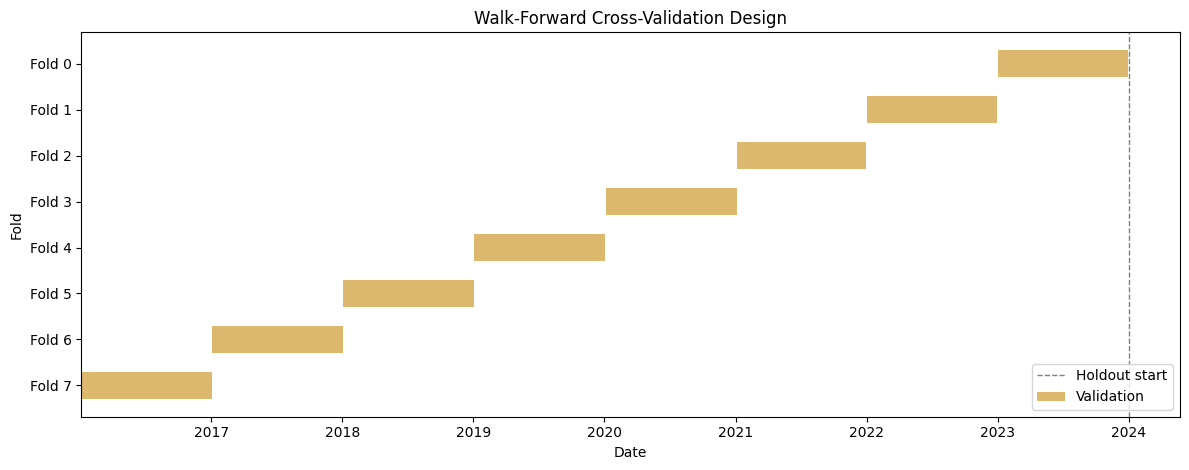

In [14]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)
    _display_current_figure()

Each fold trains on 5 years of expanding data and validates on the
following year. With 8 folds, the validation windows span a wide range
of FX regimes — from low-volatility carry-friendly periods to
sudden dollar-strength episodes and emerging-market crises.

The expanding window means later folds see more training data, but
also face more recent market structure. If a model only works in
recent folds, it may be learning from a specific dollar cycle rather
than from persistent cross-sectional structure.

### Coverage Across Modeling Chapters

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11–13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects.

In [15]:
# Predictive coverage map: family x label. Structural and causal results are
# intentionally excluded because they do not estimate predictive IC.
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (8, 6)
┌─────────┬───────────────┬─────────────┬────────────┬───────────┬───────────┐
│ chapter ┆ family        ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic   │
│ ---     ┆ ---           ┆ ---         ┆ ---        ┆ ---       ┆ ---       │
│ str     ┆ str           ┆ str         ┆ str        ┆ u32       ┆ f64       │
╞═════════╪═══════════════╪═════════════╪════════════╪═══════════╪═══════════╡
│ Ch13    ┆ deep_learning ┆ fwd_ret_1d  ┆ predictive ┆ 3         ┆ 0.010566  │
│ Ch12    ┆ gbm           ┆ fwd_ret_1d  ┆ predictive ┆ 15        ┆ 0.002474  │
│ Ch12    ┆ gbm           ┆ fwd_ret_21d ┆ predictive ┆ 15        ┆ 0.013148  │
│ Ch12    ┆ gbm           ┆ fwd_ret_5d  ┆ predictive ┆ 14        ┆ -0.005543 │
│ Ch11    ┆ linear        ┆ fwd_ret_1d  ┆ predictive ┆ 28        ┆ 0.005209  │
│ Ch11    ┆ linear        ┆ fwd_ret_21d ┆ predictive ┆ 28        ┆ 0.045005  │
│ Ch11    ┆ linear        ┆ fwd_ret_5d  ┆ predictive ┆ 28        ┆ 0.016329  │
│ Ch12

In [16]:
# Load the separate historical causal table for provenance and coverage only.
with sqlite3.connect(registry_path) as connection:
    connection.row_factory = sqlite3.Row
    causal_rows = [
        dict(row)
        for row in connection.execute(
            "SELECT causal_hash, label, treatment, dml_effect, dml_se_hac, "
            "p_value_hac, naive_effect, confounding_bias_pct, refutation_p, "
            "n_folds, n_obs, notebook, git_commit, created_at "
            "FROM causal_runs ORDER BY label"
        ).fetchall()
    ]
legacy_causal_df = pl.DataFrame(causal_rows) if causal_rows else pl.DataFrame()

In [17]:
# Primary predictive coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print("  Structural evidence: not run")
print(f"  Historical causal rows: {legacy_causal_df.height}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_1d):
  Predictive families: ['deep_learning', 'gbm', 'linear', 'tabular_dl']
  Structural evidence: not run
  Historical causal rows: 3

All labels trained: ['fwd_ret_1d', 'fwd_ret_21d', 'fwd_ret_5d']


The FX case study has four comparable predictive families on the primary
label (`fwd_ret_1d`).
Latent factor models were not trained; 20 currency pairs do not provide
the broad cross-section used by this case study's factor-model workflow.

Three horizons were explored: `fwd_ret_1d` (daily), `fwd_ret_5d`
(weekly), and `fwd_ret_21d` (monthly) — but only linear and GBM
were trained across all three. TabM and deep learning have results only
for the primary 1-day label. Causal DML uses a different estimand and its
historical rows live in `causal_runs`, not the predictive leaderboard.
The horizon panel tests whether the point-estimate ordering changes.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the
simplest possible linear model produces zero or negative IC, the
1-day FX prediction problem is too hard for this feature set.
Given that FX is the world's most efficient market, a near-zero
baseline is the expected outcome — and a pedagogically valuable one.

In [18]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                t_stat = (ic if ic is not None else 0) / (std / np.sqrt(n_splits))
                print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
            break

Linear baseline (ols):
  IC mean:  -0.0045
  IC std:   0.0294
  t-stat:   -0.4 (across 8 folds)


In [19]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model x checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (71 model x checkpoint variants):
shape: (15, 5)
┌───────────────┬────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name    ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---            ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str            ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪════════════════╪══════════════════╪══════════╪══════════╡
│ deep_learning ┆ nlinear        ┆ 45               ┆ 0.010566 ┆ 0.012025 │
│ deep_learning ┆ tcn            ┆ 60               ┆ 0.009935 ┆ 0.018115 │
│ tabular_dl    ┆ tabm_s         ┆ 25               ┆ 0.009619 ┆ 0.014914 │
│ deep_learning ┆ nlinear        ┆ 30               ┆ 0.009565 ┆ 0.014327 │
│ tabular_dl    ┆ tabm_s         ┆ 50               ┆ 0.00702  ┆ 0.02514  │
│ …             ┆ …              ┆ …                ┆ …        ┆ …        │
│ linear        ┆ ridge_a10000.0 ┆ null             ┆ 0.005209 ┆ 0.037937 │
│ tabular_dl    ┆ tabm_l 

**The OLS baseline is negative** at IC = -0.0045 (naive fold t = -0.4), confirming
that unregularized linear regression fails on 1-day FX returns. With
51 features and only 20 instruments per cross-section, OLS overfits
aggressively. The best linear model (ridge $\alpha = 10^4$,
IC = +0.0052, t_HAC = 0.60) barely crosses zero.

NLinear leads at IC = +0.0106 (HAC CI [-0.0049, +0.0261],
$p_{HAC}=0.181$). TabM-S at physical epoch 25 follows at +0.0096
(CI [-0.0035, +0.0227], $p_{HAC}=0.149$), ahead of ridge
$\alpha = 10^4$ at +0.0052 and GBM `leaves_63_mae` at +0.0025.
All four CIs straddle zero.

The two nonlinear leaders are nearly tied and neither clears the uncertainty
threshold. Whether their small point estimates persist across folds is the
next question.

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated not just by mean IC but by consistency across 8 folds.
With only 20 pairs per cross-section, individual fold ICs will be
noisy — a model that appears to lead may do so by chance in a few
windows.

In [20]:
# Build fold x family IC matrix from raw predictions
fold_ic = (
    fold_performance_matrix(best_preds, date_col=DATE_COL)
    if best_preds.height > 0
    else pl.DataFrame()
)

### Figure 2: Fold-by-Model Performance Heatmap

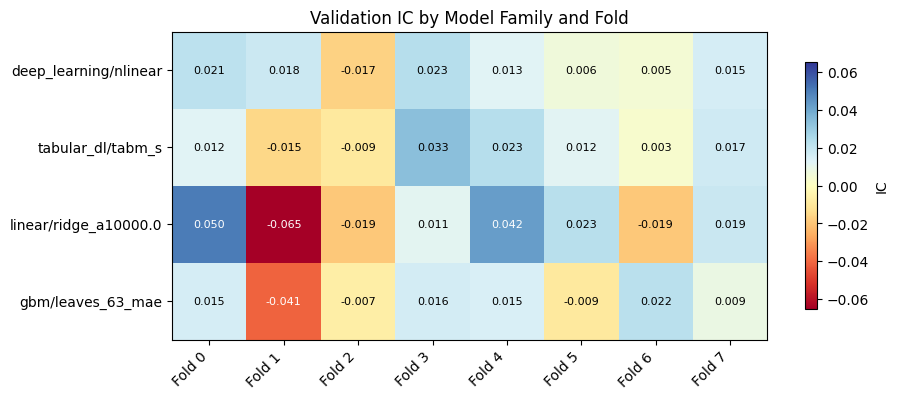

In [21]:
if fold_ic.height > 0:
    model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)
    for annotation in list(plt.gcf().axes[0].texts):
        if annotation.get_position()[0] > len(fold_cols):
            annotation.remove()
    _display_current_figure()
else:
    model_labels, fold_cols, matrix = [], [], np.array([])

In [22]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (4, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ deep_learnin ┆ 0.010566 ┆ 0.013962  ┆ 0.012856 ┆ -0.016774  ┆ 0.023017  ┆ 0.875        ┆ 8       │
│ g/nlinear    ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ tabular_dl/t ┆ 0.009619 ┆ 0.012173  ┆ 0.015943 ┆ -0.014839  ┆ 0.033135  ┆ 0.75         ┆ 8       │
│ abm_s        ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ linear/ridge ┆ 0.005209 ┆ 0.014936  ┆ 0.037937 

The heatmap shows that the ranking is small relative to fold variation:

- **NLinear** leads at +0.0106 and is positive in seven of eight folds.
- **TabM-S** at epoch 25 follows at +0.0096 and is positive in six folds.
- **Ridge** posts +0.0052 and is positive in five folds, but its worst fold
  reaches -0.0652.
- **GBM** is near breakeven at +0.0025 and is also positive in five folds.

These are validation rankings, not evidence that nonlinear architecture
identifies a specific economic mechanism.

## 4. Stability Over Time

Mean IC can be misleading when carried by a few strong folds.
For a daily rebalancing strategy on 20 FX pairs, consistency
matters more than peak performance. A model that delivers
IC = 0.01 reliably is a better foundation than one that
delivers IC = 0.05 in one fold and IC = −0.03 in seven.

### Figure 3: Fold Performance Distribution by Model Family

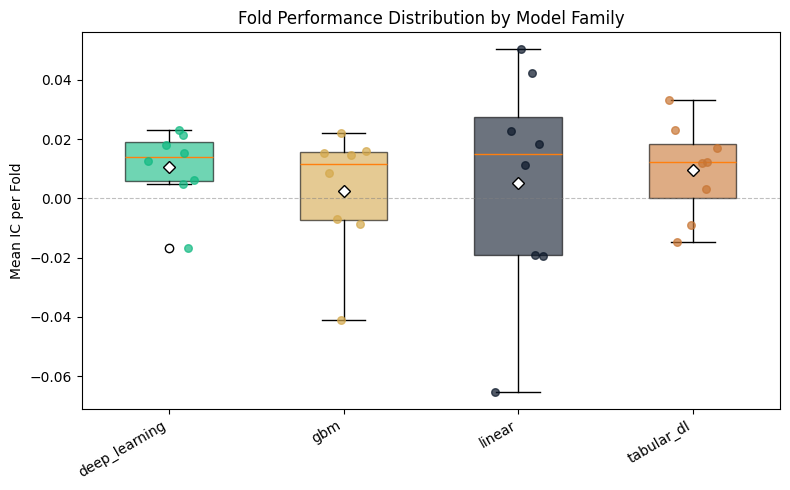

In [23]:
if fold_ic.height > 0:
    plot_fold_boxplot(fold_ic)
    _display_current_figure()

The box plots make the dispersion explicit:

- NLinear has mean +0.0106, median +0.0140, and range [-0.0168, +0.0230].
- TabM-S has mean +0.0096, median +0.0122, and range [-0.0148, +0.0331].
- GBM has mean +0.0025, median +0.0115, and range [-0.0409, +0.0220].
- Ridge has mean +0.0052, median +0.0149, and the widest range,
  [-0.0652, +0.0502].

Every family has at least one negative fold. The narrow cross-section makes
the worst-fold behavior material even when the pooled point estimate is positive.

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized 1-day returns? With only 5 quintile buckets (4 pairs each),
   monotonicity is a weaker test than with 10 deciles.
2. **Diversity**: do different model families produce similar or
   different rankings? If all families agree, the signal (whatever
   exists) is simple and linear. If they diverge, there may be
   ensemble potential — or one family may be fitting noise.

In [24]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (1–3 bps per leg):
  deep_learning         spread=+1 bps  edge/cost=0.5–0.2x
  tabular_dl            spread=+1 bps  edge/cost=0.7–0.2x
  linear                spread=-0 bps  edge/cost=-0.1–-0.0x
  gbm                   spread=+0 bps  edge/cost=0.2–0.1x


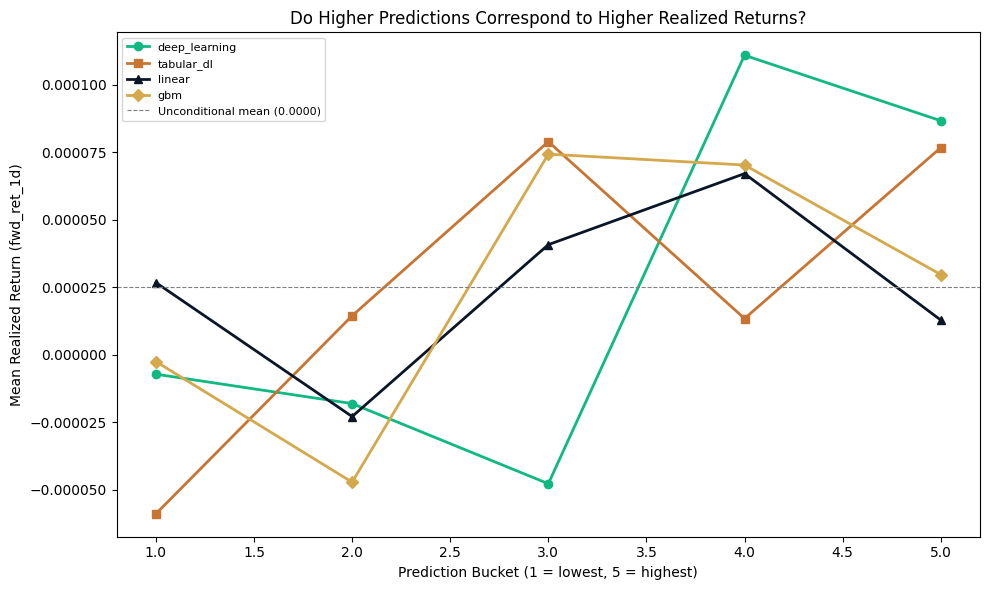

In [25]:
if bucket_results:
    unconditional_mean = best_preds["y_true"].mean() if best_preds.height > 0 else None
    plot_bucket_monotonicity(
        bucket_results,
        N_BUCKETS,
        unconditional_mean=unconditional_mean,
        label_name=f"Return ({PRIMARY_LABEL})",
        cost_range=cost_range,
    )
    _display_current_figure()

The bucket plot does not reveal an economically large separation:

- TabM-S has the largest top-minus-bottom spread at about +1.36 bps.
- NLinear follows at about +0.94 bps, GBM at +0.32 bps, and Ridge at
  -0.14 bps.

Even the largest gross spread is below the stated 2-6 bps round-trip cost
range before turnover and slippage. None clears an economic gate here.

In [26]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.11
Range: -0.08 to 0.43


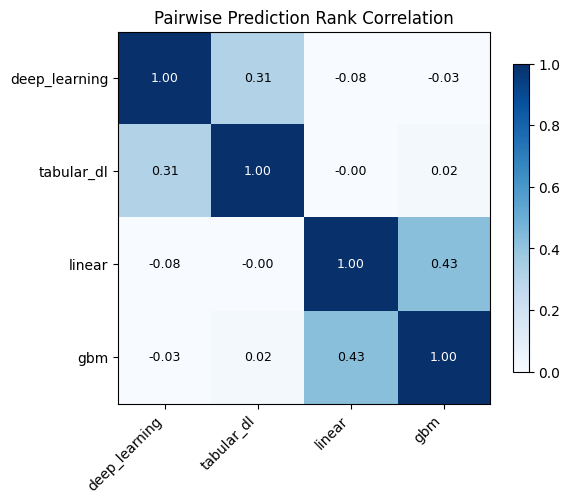

In [27]:
if corr_matrix.size > 0 and len(corr_labels) >= 2:
    plot_correlation_matrix(corr_matrix, corr_labels)
    _display_current_figure()

The four selected forecasts have average pairwise rank correlation 0.11,
ranging from -0.08 to 0.43. Low correlation creates an ensemble candidate,
but it does not establish that each component contains independent signal.
The backtest must determine whether combination reduces noise or dilutes the
already small gross spreads.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. In a low-signal environment like FX, overfitting is
the dominant risk — additional complexity is more likely to fit noise
than to discover latent structure.

In [28]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['deep_learning', 'tabular_dl']


### Figure 6: Learning Curves

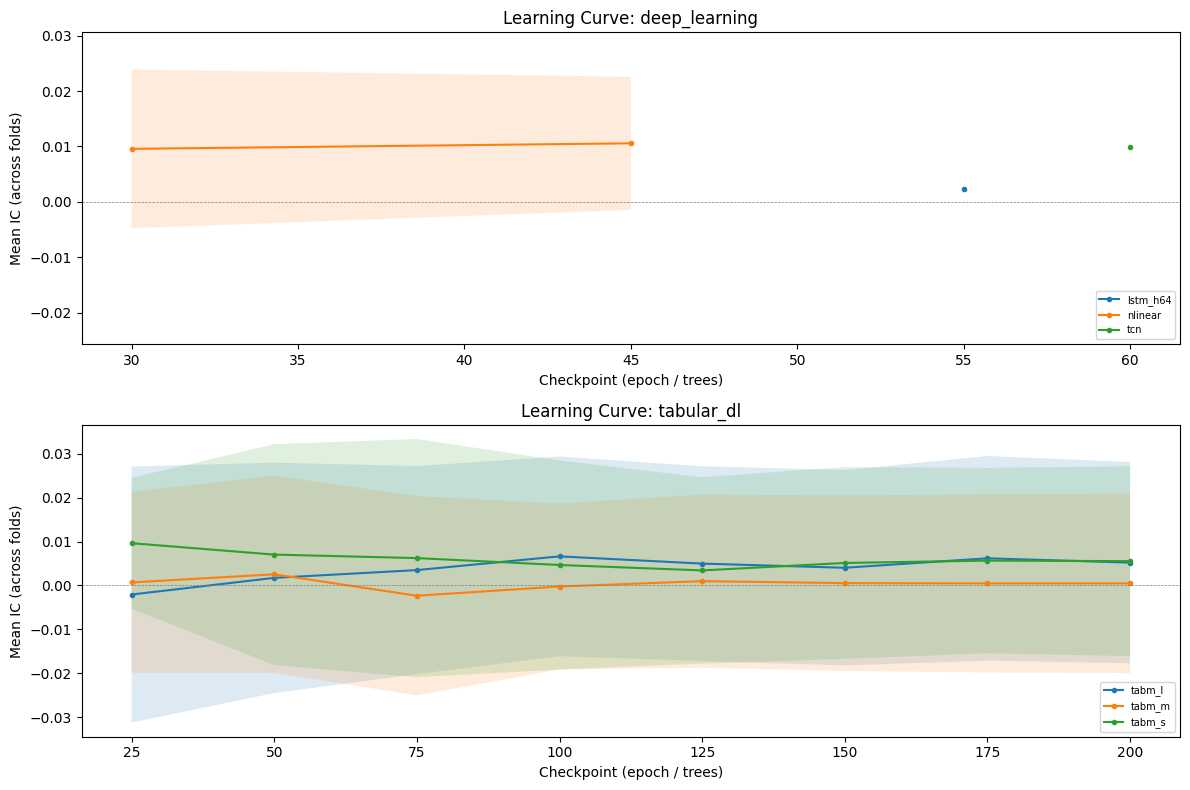

In [29]:
if cp_families:
    plot_learning_curves(cp_data, cp_families)
    _display_current_figure()

Two families have physical checkpoint data in this registry vintage:

- TabM-S peaks at epoch 25; TabM-M peaks at 50 and TabM-L at 100.
- NLinear has persisted epochs 30 and 45, with epoch 45 leading.
  TCN and LSTM each have one persisted checkpoint and therefore do not
  define a within-model learning curve.

The paths support checkpoint selection only. They do not isolate whether
later changes arise from overfitting, optimization noise, or model vintage.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. Recurring
importance across 8 walk-forward folds is evidence. For FX pairs,
the academic prior is clear: carry (interest rate differentials)
should be the dominant feature if any signal exists. Momentum
features may contribute at intermediate horizons, but at the 1-day
level, momentum in FX is notoriously weak.

In [30]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)
importance_rows = []

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions=datetime[ms], features may be date)
            if features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

The fallback is normalized within each fold before selecting the 15 features
with the highest mean association.

In [31]:
if gbm_importance is None and importance_rows:
    gbm_importance = pl.DataFrame(importance_rows).with_columns(
        (pl.col("importance") / pl.col("importance").max().over(["config_name", "fold_id"])).alias(
            "importance_norm"
        )
    )
    top_features = (
        gbm_importance.group_by("feature")
        .agg(pl.col("importance_norm").mean().alias("mean_imp"))
        .sort("mean_imp", descending=True)
        .head(TOP_N_FEATURES)["feature"]
        .to_list()
    )
    gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
    print(
        f"Computed feature-prediction correlation for {len(top_features)} features "
        f"across {merged['fold_id'].n_unique()} folds"
    )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features x {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features x 8 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['usd_factor_1d', 'usd_factor_63d']


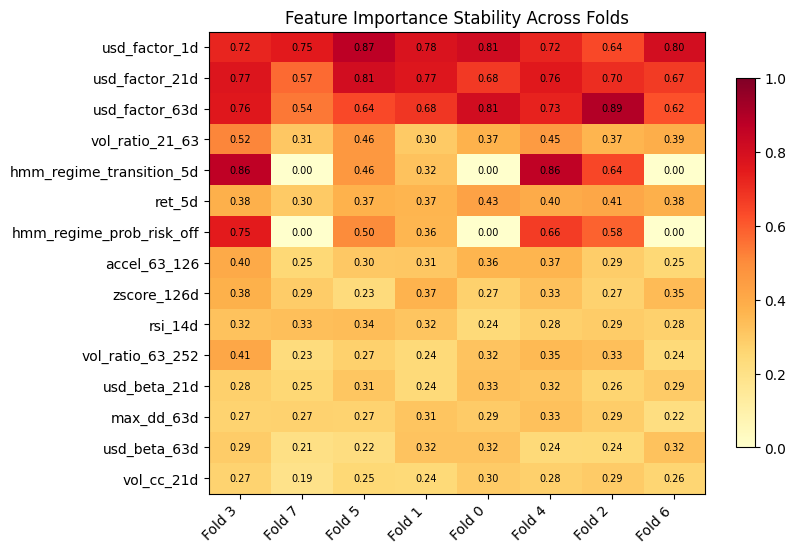

In [32]:
if gbm_importance is not None and gbm_importance.height > 0:
    plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)
    _display_current_figure()

The executed analysis finds saved LightGBM boosters and aggregates normalized
gain importance across 15 GBM configurations and 8 walk-forward folds. The
heatmap therefore describes recurring split gains in the nonlinear family;
the Ridge prediction-correlation proxy above is only a conditional fallback
for an environment without those booster artifacts.

The feature set spans carry (`carry_proxy`, `rank_carry_proxy`),
momentum (`ret_5d` through `ret_252d`, `rank_ret_*`), risk-adjusted
momentum (`sharpe_*`, `rank_sharpe_*`), volatility (`vol_gk_*`,
`vol_cc_*`), USD factor loadings (`usd_beta_*`, `usd_factor_*`),
technical indicators (`rsi_*`, `bollinger_*`, `channel_pos_*`),
and mean-reversion signals (`zscore_*`).

`usd_factor_1d`, `usd_factor_21d`, and `usd_factor_63d` have the three largest
mean normalized gains. This supports a USD-common-factor reading, while gain
importance still does not establish that any feature is an economic cause.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal strengthen or
weaken at longer horizons? And does model ranking depend on the
market regime? Both matter for strategy design.

### Multi-Label Comparison

Three horizons were explored: the primary `fwd_ret_1d` (daily),
`fwd_ret_5d` (weekly), and `fwd_ret_21d` (monthly). Only linear and
GBM are trained on all three; deep_learning and tabular_dl run only
at the daily horizon, and latent factors / causal DML are not trained
on this case study at all. The forest below renders the highest-IC
config per family for each horizon as a point estimate with the HAC
95% CI.
Tiles labeled "no run" mean a family was not trained on that label.

In [33]:
multi_rows = []
for lbl in [PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL]:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_1d""","""tabular_dl""","""tabm_s""",0.009619,-0.003455,0.022693,1.442903
"""fwd_ret_1d""","""linear""","""ridge_a10000.0""",0.005209,-0.011945,0.022362,0.595475
"""fwd_ret_1d""","""deep_learning""","""nlinear""",0.010566,-0.004936,0.026069,1.336655
"""fwd_ret_1d""","""gbm""","""leaves_63_mae""",0.002474,-0.013061,0.01801,0.31233
"""fwd_ret_21d""","""linear""","""lasso_f0.35""",0.045005,-0.013374,0.103384,1.511832
"""fwd_ret_21d""","""gbm""","""leaves_7_mae""",0.013148,-0.039501,0.065797,0.489738
"""fwd_ret_5d""","""linear""","""lasso_f0.7""",0.016329,-0.015953,0.048612,0.99198
"""fwd_ret_5d""","""gbm""","""default_mae""",-0.005543,-0.031922,0.020836,-0.412079


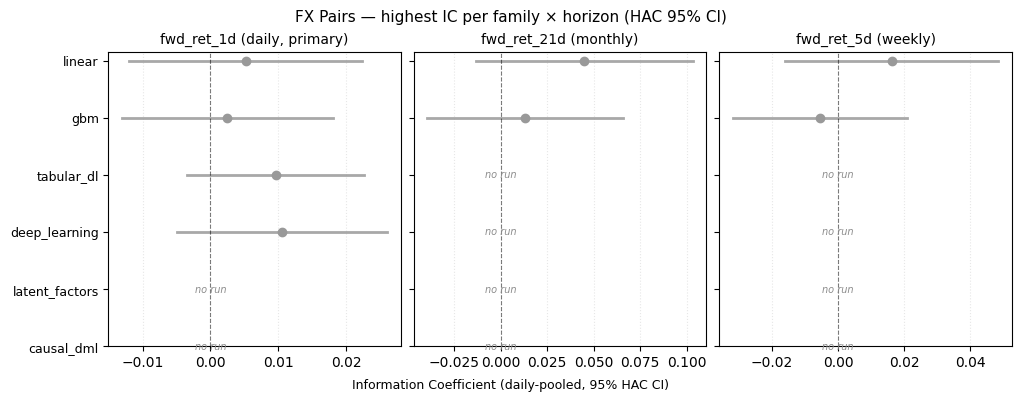

In [34]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=[PRIMARY_LABEL] + [l for l in all_labels if l != PRIMARY_LABEL],
    label_display={
        "fwd_ret_1d": "fwd_ret_1d (daily, primary)",
        "fwd_ret_5d": "fwd_ret_5d (weekly)",
        "fwd_ret_21d": "fwd_ret_21d (monthly)",
    },
    title="FX Pairs — highest IC per family × horizon (HAC 95% CI)",
)
_display_current_figure()

Coverage is the first observation. The daily panel has runs for four
families (linear, GBM, tabular_dl, deep_learning); the weekly and
monthly panels have runs only for linear and GBM.
Latent factors are absent across all three panels. Causal DML is omitted
because a treatment effect is not a predictive IC and is reported separately.

Within the families that span horizons, the IC magnitudes are not
horizon-monotone and CIs straddle zero everywhere. At the daily
horizon the highest-IC configs by family are deep_learning NLinear (+0.0106,
CI [-0.0049, +0.0261], t_HAC=1.34), tabular_dl TabM-S (+0.0096,
CI [-0.0035, +0.0227], t_HAC=1.44), linear ridge $\alpha=10^4$
(+0.0052, CI [-0.0119, +0.0224], t_HAC=0.60), and GBM leaves_63_mae
(+0.0025, CI [-0.0131, +0.0180], t_HAC=0.31) — all `straddles_zero`.
At the weekly horizon GBM (`default_mae`) is mildly negative (-0.0055,
CI [-0.0319, +0.0208], t_HAC=-0.41) and linear Lasso (`lasso_f0.7`) is positive
(+0.0163, CI [-0.0160, +0.0486]). At the monthly horizon linear
Lasso (`lasso_f0.35`) posts the largest point estimate of the comparison
(+0.0450, CI [-0.0134, +0.1034], t_HAC=1.51) and GBM
leaves_7_mae sits at +0.0131 (CI [-0.0395, +0.0658]); both still
straddle zero, with confidence intervals that widen substantially as
the horizon stretches and the effective number of independent
observations shrinks.

Family ranking is not horizon-stable. Linear is the largest point
estimate at 21d but the third-largest at 1d; GBM is the smallest at
1d, mildly negative at 5d, and the second-largest at 21d. No family
clears the credibility line at any horizon, so the apparent
"monthly is stronger" reading from older runs no longer survives the
locked, daily-pooled HAC interval — the wider monthly CIs swamp the
point-estimate bump. The qualitative reading is therefore narrower
than before: at every horizon the cross-sectional signal is
`below_credibility` or `straddles_zero`, and the choice of horizon
changes which family is the largest point estimate but not the
overall conclusion.

### Regime Conditioning

FX carry strategies famously crash during "risk-off" episodes — sudden
dollar-strength moves where high-yielding currencies (AUD, NZD, EM
crosses) sell off sharply against safe-haven currencies (JPY, CHF, USD).
These carry unwinds are the defining tail risk of FX investing.

We condition performance on a volatility regime derived from
cross-sectional return dispersion — a natural proxy for dollar-strength
episodes and macro uncertainty.

In [35]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

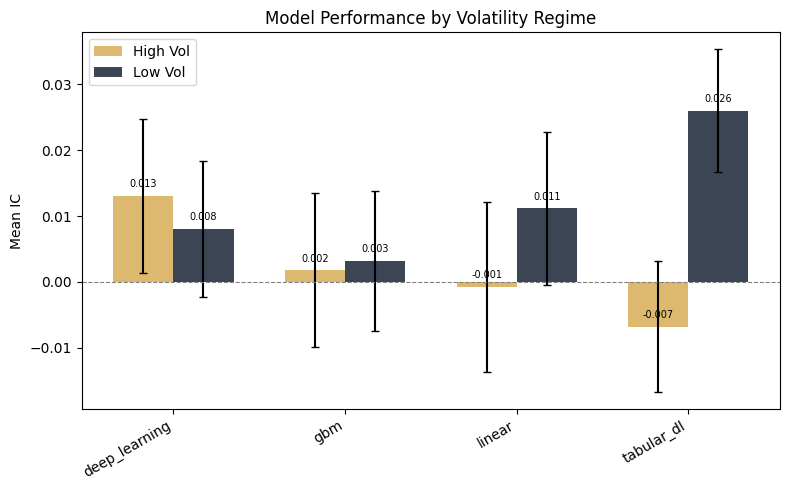

In [36]:
if regime_df.height > 0:
    plot_regime_bars(regime_df)
    _display_current_figure()

NLinear is positive in both halves of the dispersion split. TabM-S is
negative in the high-volatility half (-0.0068) and positive in the
low-volatility half (+0.0260). Ridge and GBM remain close to zero. This is
an exploratory partition selected on the same validation sample, with no
multiplicity adjustment, so it does not authorize regime-based sizing.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Latent factor models were **not trained** for the FX pairs case study.
With only 20 currency pairs, the cross-section is far too narrow for
PCA, CAE, SDF, or SAE to extract stable latent factors — these methods
require hundreds to thousands of entities. Moreover, FX returns are
driven almost entirely by a single common factor (dollar strength),
making factor decomposition redundant. This is itself an analytical
conclusion: for narrow, macro-driven cross-sections, direct supervised
prediction is more appropriate than factor extraction.

### Causal DML (Ch15)

In [37]:
if legacy_causal_df.height:
    legacy_causal_df = legacy_causal_df.with_columns(
        pl.when(pl.col("label") == PRIMARY_LABEL)
        .then(pl.lit("superseded primary"))
        .otherwise(pl.lit("historical, not re-audited"))
        .alias("vintage_status")
    )
    print("Frozen v3.0 causal_runs rows - separate from the predictive leaderboard:")
    print(
        legacy_causal_df.select(
            "label",
            "treatment",
            pl.col("dml_effect").round(6).alias("ate"),
            pl.col("dml_se_hac").round(6).alias("se_hac"),
            pl.col("p_value_hac").round(3).alias("p_hac"),
            pl.col("refutation_p").round(2).alias("ref_p"),
            pl.col("n_folds").cast(pl.Int64).alias("folds"),
            pl.col("n_obs").cast(pl.Int64).alias("n"),
            "git_commit",
            "vintage_status",
        )
    )
else:
    print("No causal_runs rows for this case study")

Frozen v3.0 causal_runs rows - separate from the predictive leaderboard:
shape: (3, 10)
┌─────────────┬──────────────┬───────────┬──────────┬───┬───────┬───────┬────────────┬─────────────┐
│ label       ┆ treatment    ┆ ate       ┆ se_hac   ┆ … ┆ folds ┆ n     ┆ git_commit ┆ vintage_sta │
│ ---         ┆ ---          ┆ ---       ┆ ---      ┆   ┆ ---   ┆ ---   ┆ ---        ┆ tus         │
│ str         ┆ str          ┆ f64       ┆ f64      ┆   ┆ i64   ┆ i64   ┆ str        ┆ ---         │
│             ┆              ┆           ┆          ┆   ┆       ┆       ┆            ┆ str         │
╞═════════════╪══════════════╪═══════════╪══════════╪═══╪═══════╪═══════╪════════════╪═════════════╡
│ fwd_ret_1d  ┆ mom_skip_rec ┆ 0.000356  ┆ 0.000849 ┆ … ┆ 5     ┆ 41665 ┆ 6a332d5    ┆ superseded  │
│             ┆ ent          ┆           ┆          ┆   ┆       ┆       ┆            ┆ primary     │
│ fwd_ret_21d ┆ mom_skip_rec ┆ -0.004062 ┆ 0.005604 ┆ … ┆ 5     ┆ 41646 ┆ 8c6eda7    ┆ historical, │
│  

These rows document the frozen v3.0 registry and are not current estimates.
Notebook 11 found that the primary row used row-indexed folds that admitted
sealed dates and could split a decision-time panel. Its corrected
`panel_time_v3` estimate and symbolwise block placebo both fail their gates,
so the causal disposition remains "no identified effect," but the legacy
primary sign and magnitude above must not be reused. The 5-day and 21-day
rows have not received the same correction and remain historical evidence.

### Calibration: Do Prediction Intervals Reach Nominal Coverage?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [38]:
conformal_rows = []
for (family, config), frame in best_preds.partition_by(
    ["family", "config_name"], as_dict=True, maintain_order=True
).items():
    frame = frame.drop_nulls(["y_true", "y_score"]).with_columns(
        (pl.col("y_true") - pl.col("y_score")).abs().alias("abs_resid")
    )
    fold_ids = sorted(frame["fold_id"].unique().to_list())
    calibration = frame.filter(pl.col("fold_id") == fold_ids[0])
    test = frame.filter(pl.col("fold_id").is_in(fold_ids[1:]))
    calibration_residuals = calibration["abs_resid"].to_numpy()
    test_residuals = test["abs_resid"].to_numpy()
    scale = float(frame["y_true"].std())
    n_calibration = len(calibration_residuals)
    for level in (0.80, 0.90, 0.95):
        quantile_level = min(np.ceil((n_calibration + 1) * level) / n_calibration, 1.0)
        quantile = float(np.quantile(calibration_residuals, quantile_level))
        conformal_rows.append(
            {
                "family": family,
                "config_name": config,
                "nominal_level": level,
                "empirical_coverage": float((test_residuals <= quantile).mean()),
                "mean_interval_width_frac_std": 2.0 * quantile / scale,
                "n_test": len(test_residuals),
            }
        )
conformal_df = pl.DataFrame(conformal_rows).sort(["family", "nominal_level"])
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""nlinear""",0.8,0.751772,5.040013,36120
"""deep_learning""","""nlinear""",0.9,0.822924,7.197059,36120
"""deep_learning""","""nlinear""",0.95,0.846069,9.346706,36120
"""gbm""","""leaves_63_mae""",0.8,0.781285,2.220649,36120
"""gbm""","""leaves_63_mae""",0.9,0.883666,3.039823,36120
…,…,…,…,…,…
"""linear""","""ridge_a10000.0""",0.9,0.890421,3.009735,36120
"""linear""","""ridge_a10000.0""",0.95,0.941639,3.827198,36120
"""tabular_dl""","""tabm_s""",0.8,0.651052,2.235221,36120


In [39]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (4, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear    ┆ 0.751772   ┆ 0.822924  ┆ 0.846069  ┆ 5.040013  ┆ 7.197059  ┆ 9.346706  │
│ ing  

Linear (ridge $\alpha=10^4$) and GBM (`leaves_63_mae`) track
nominal coverage tightly (linear: 0.796 / 0.890 / 0.942 against
0.80 / 0.90 / 0.95; GBM: 0.781 / 0.884 / 0.936) and produce the
tightest intervals per std-of-returns (≈2.2σ at 80% rising to ≈3.8σ
at 95% for both). TabM-S under-covers more substantially at 0.651 /
0.745 / 0.796 with widths of roughly 2.2-3.9σ. NLinear reaches
0.752 / 0.823 / 0.846, but requires much wider 5.0-9.3σ intervals.
Fold 0 is only a diagnostic calibration sample, so these results do not
establish future coverage. They do show that the selected nonlinear score
scales are less stable across folds than the linear and GBM baselines.

## 8. Pre-Backtest Judgment and Handoff

The next backtest is an economic diagnostic, not a deployment decision.
Positive median IC, a majority of positive folds, and a positive bucket
spread qualify a model for that diagnostic. Statistical and cost gates remain
separate, and none of the predictive families clears both here.

In [40]:
spread_rows = []
for family, buckets in bucket_results.items():
    spread = (
        buckets.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
        - buckets.filter(pl.col("bucket") == 1)["mean_return"][0]
    )
    spread_rows.append({"family": family, "spread_bps": spread * 10000})
spread_df = pl.DataFrame(spread_rows)

The final table joins checkpoint-level IC, fold stability, and gross bucket
spread before applying the research-backtest rule stated above.

In [41]:
synthesis = (
    best_per_family.with_columns(
        (pl.col("family") + pl.lit("/") + pl.col("config_name")).alias("model_label")
    )
    .join(
        family_stats.rename({"pct_positive": "fold_pct_positive"}),
        on="model_label",
        how="left",
    )
    .join(spread_df, on="family", how="left")
    .with_columns(
        pl.when(
            (pl.col("median_ic") > 0)
            & (pl.col("fold_pct_positive") > 0.6)
            & (pl.col("spread_bps") > 0)
        )
        .then(pl.lit("Research backtest"))
        .when(pl.col("ic_mean") > 0)
        .then(pl.lit("Benchmark only"))
        .otherwise(pl.lit("Exclude"))
        .alias("recommendation")
    )
    .select(
        "family",
        pl.col("config_name").alias("config"),
        pl.col("ic_mean").round(4),
        pl.col("median_ic").round(4).alias("ic_median"),
        pl.col("std_ic").round(4).alias("ic_std"),
        pl.col("fold_pct_positive").round(2).alias("pct_positive"),
        pl.col("worst_fold").round(4),
        pl.col("spread_bps").round(1),
        "recommendation",
    )
    .sort("ic_mean", descending=True)
)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (4, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ recommend │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ation     │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ str       │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear   ┆ 0.0106  ┆ 0.014     ┆ … ┆ 0.88      ┆ -0.0168   ┆ 0.9       ┆ Research  │
│ ing        ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆ backtest  │
│ tabular_dl ┆ tabm_s    ┆ 0.0096  ┆ 0.0122    ┆ … ┆ 0.75      ┆ -0.0148   ┆ 1.4       ┆ Research  │
│            ┆           ┆         ┆           ┆   ┆        

### Recommendations

**Research backtest candidates:**
- **NLinear**: IC +0.0106, seven positive folds, and about +0.94 bps
  top-minus-bottom spread. Its HAC interval still crosses zero.
- **TabM-S**: IC +0.0096 at physical epoch 25, six positive folds,
  and the largest spread at about +1.36 bps. Its HAC interval also crosses zero.
- **GBM**: IC +0.0025, five positive folds, and about +0.32 bps spread.
  It is a nonlinear-family control, not a credible standalone edge.

**Benchmark:** Ridge (+0.0052) retains the regularized linear reference, but
its top-minus-bottom spread is slightly negative.
Causal DML is not a forecast and does not enter the backtest candidate set;
Notebook 11's corrected primary estimate clears neither causal gate.

### Forecast Representation

For backtesting, predictions should be used as:
- **Rank-based selection**: sort by `y_score`, go long top quintile
  (4 pairs) and short bottom quintile (4 pairs)
- **Score weighting**: use `y_score` magnitudes for position sizing,
  but cap individual pair exposure given the 20-pair universe
- **Ensemble test**: average pairwise correlation is 0.11, but Ch20 must
  test whether combining these weak components improves net performance

### What This Analysis Does Not Tell Us

- **Turnover costs**: daily rebalancing on a 20-pair cross-section
  may generate high turnover. Even at 1–3 bps per leg, frequent
  portfolio rotations would erode the thin NLinear edge quickly.
- **Regime mechanism**: every family has a negative fold, but this
  validation analysis does not establish that those folds correspond to
  carry unwinds or authorize a position-sizing rule.
- **Out-of-sample degradation**: with only 20 pairs and 8 folds,
  the statistical evidence is thin. IC estimates have wide confidence
  intervals, and the true population IC may be materially lower.
- **Longer horizons do not yet clear the CI bar either**: the
  multi-label comparison shows the largest 21-day point estimate
  from linear `lasso_f0.35` (+0.045, t≈1.51, CI [-0.013, 0.103]),
  with GBM `leaves_7_mae` at +0.013 (t≈0.49). Both straddle zero;
  the horizon-effect ordering is a point-estimate ranking, not a
  statistically distinguishable improvement.
- **Capacity**: FX is the world's most liquid market. Capacity is
  not a binding constraint.

**Next**: [`13_backtest`](13_backtest.ipynb) for strategy simulation,
`15_portfolio_management.py` for position sizing, and
`18_synthesis.py` for end-to-end results.

The publication registry must remain unchanged throughout this audit.

In [42]:
registry_after = _file_md5(registry_path)
if registry_after != registry_before:
    raise RuntimeError("Model analysis modified the frozen registry")
print(f"Registry unchanged: {registry_after}")

Registry unchanged: 7701a4a83a6ebaace13aecf6f9fb94b0


## Key Takeaways

1. **Weak validation rankings, no cleared credibility gate**: the four
   selected 1-day predictive families range from +0.0025 to +0.0106,
   and every HAC interval includes zero.
2. **The horizon panel is a point-estimate ordering, not a credibility
   claim**: the longer-horizon panels at 5d and 21d are populated only
   for linear and GBM. The largest point estimate is linear `lasso_f0.35`
   at 21d (+0.045, t≈1.51); GBM `leaves_7_mae` sits at +0.013
   (t≈0.49). Both CIs straddle zero, so the horizon-effect ordering
   is a useful framing for where to look next, not a statistically
   distinguishable improvement at this sample size.
3. **The nonlinear leaders are close**: NLinear is +0.0106 with seven
   positive folds; TabM-S is +0.0096 with six. Neither clears the HAC
   credibility line.
4. **Low prediction correlation is a testable opportunity**: average
   pairwise correlation is 0.11, but only a backtest can show whether
   combination adds signal rather than noise.
5. **FX costs are tight against any of these edges**: at 1–3 bps per
   leg, even the NLinear point estimate leaves little headroom.
   Turnover discipline matters more than family choice.
6. **Causal evidence stays separate**: the frozen `causal_runs` rows are
   historical. Notebook 11's corrected primary estimate and placebo both
   fail their gates, so there is no identified treatment effect to promote.

**Next**: [`13_backtest`](13_backtest.ipynb) applies these predictions to simulated trading.